In [2]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Load the dataset
df = pd.read_csv('diabetes_prediction_dataset.csv')

# 1. DATA CLEANING
# Remove the 18 rows where gender is 'Other' (noisy data / insignificant outlier)
df = df[df['gender'] != 'Other']

# Note: 'No Info' in smoking_history is kept as a valid 'unknown' category for encoding, as it may provide useful information for the model.

# 2. DATA TRANSFORMATION (Encoding)
# One-Hot Encode categorical variables: 'gender' and 'smoking_history'
# drop_first=True helps avoid the dummy variable trap
df_encoded = pd.get_dummies(df, columns=['gender', 'smoking_history'], drop_first=True)

# 3. DATA TRANSFORMATION (Scaling)
# Standardize the numerical features
scaler = StandardScaler()
num_cols = ['age', 'bmi', 'HbA1c_level', 'blood_glucose_level']
df_encoded[num_cols] = scaler.fit_transform(df_encoded[num_cols])

# Save the final preprocessed dataset
df_encoded.to_csv('cleaned_diabetes_dataset.csv', index=False)

            age       bmi  HbA1c_level  blood_glucose_level
count  99982.00  99982.00     99982.00             99982.00
mean      -0.00      0.00         0.00                 0.00
std        1.00      1.00         1.00                 1.00
min       -1.86     -2.61        -1.89                -1.43
25%       -0.79     -0.56        -0.68                -0.93
50%        0.05     -0.00         0.25                 0.05
75%        0.80      0.34         0.63                 0.51
max        1.69     10.30         3.24                 3.98


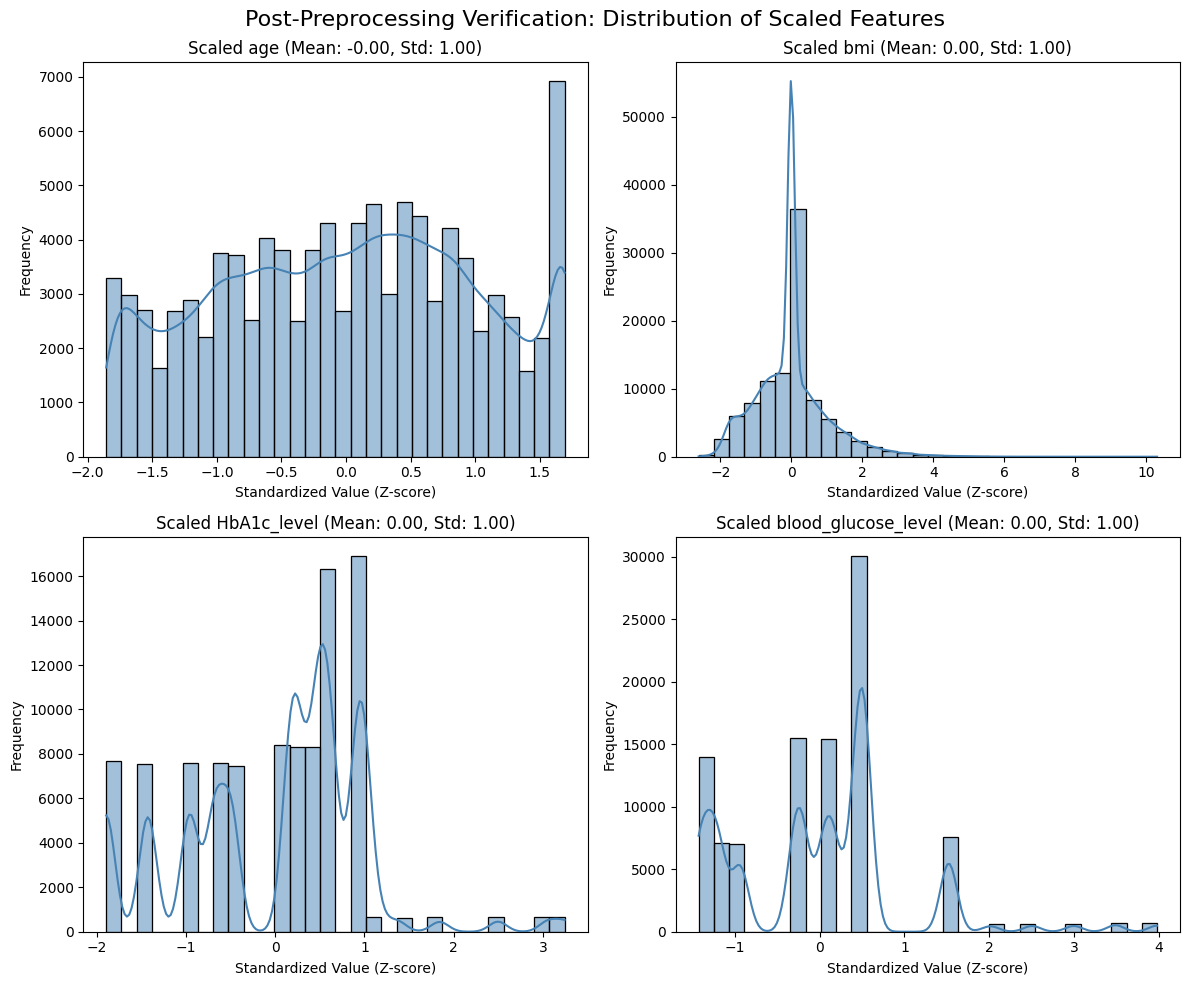

In [1]:
# 4. POST-PREPROCESSING VERIFICATION
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the cleaned dataset
df_cleaned = pd.read_csv('cleaned_diabetes_dataset.csv')

# Select the scaled numerical columns
num_cols = ['age', 'bmi', 'HbA1c_level', 'blood_glucose_level']

# Create a figure with subplots
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Post-Preprocessing Verification: Distribution of Scaled Features', fontsize=16)

# Plot distributions for each scaled feature
for i, col in enumerate(num_cols):
    ax = axes[i//2, i%2]
    sns.histplot(df_cleaned[col], kde=True, ax=ax, color='steelblue', bins=30)
    ax.set_title(f'Scaled {col} (Mean: {df_cleaned[col].mean():.2f}, Std: {df_cleaned[col].std():.2f})')
    ax.set_xlabel('Standardized Value (Z-score)')
    ax.set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('post_preprocessing_verification.png')

# Print the statistical summary to verify mean=0 and std=1
print(df_cleaned[num_cols].describe().round(2))